# DySAT-Inspired Model — Standalone Convergence Diagnostic

Isolated from the full AgroVedha notebook to test whether the DySAT-inspired model converges with a longer training budget and a fixed architecture. In the full-notebook run, it produced **negative R²** (RMSE 10.85, R²=-0.016) after 3 epochs on a 3,000-row subsample — worse than predicting the mean.

**Two things changed here vs. the original**, both suspected root causes, not just "more epochs":
1. **`d_model` was 1 in the original** — meaning the Transformer's temporal self-attention had a single scalar per timestep to work with, essentially no room to represent anything. Fixed to a real embedding dimension (16) via an input projection layer.
2. **No gradient clipping / lower LR in the original** — Transformer components are notoriously sensitive to this; both added here.

Remember this remains a **simplified, DySAT-inspired approximation** (temporal self-attention over each node's window + GAT-style structural attention across nodes) — not a reimplementation of the published DySAT architecture. State that plainly if this is referenced in your report.


## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
!pip install torch_geometric --no-deps -q
!pip install networkx decorator six -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00a 0:00:01


In [5]:
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)
loss_fn = nn.MSELoss()

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

Using device: cpu


## Subsampling — this model's per-sample loop is expensive

Every sample requires a full Transformer forward pass per node, per batch item — looping over the whole 33k-row training set every epoch is impractical in a normal session. Subsampling is a **stated compute-constrained design choice**, not something to hide in your report. `SUBSAMPLE_SIZE` is easy to raise if your session can tolerate a longer run.


In [6]:
SUBSAMPLE_SIZE = 6000  # raise this if you have time/patience for a longer run

subsample_idx = np.random.RandomState(42).choice(len(X_train_t), size=min(SUBSAMPLE_SIZE, len(X_train_t)), replace=False)
X_train_sub = X_train_t[subsample_idx]
y_train_sub = y_train_t[subsample_idx]

test_subsample_idx = np.random.RandomState(43).choice(len(X_test_t), size=min(1500, len(X_test_t)), replace=False)
X_test_sub = X_test_t[test_subsample_idx]
y_test_sub_true = target_scaler_g.inverse_transform(y_test_g[test_subsample_idx].reshape(-1, 1)).flatten()

sub_batch_size = 64
n_sub_batches = len(X_train_sub) // sub_batch_size
print(f"Train subsample: {len(X_train_sub)}  Test subsample: {len(X_test_sub)}  Batches/epoch: {n_sub_batches}")

Train subsample: 6000  Test subsample: 1500  Batches/epoch: 93


## DySAT-Inspired Model (fixed) — real embedding dimension, gradient clipping

Fixes applied vs. the original run that produced negative R²:
- **`d_model=16` input projection** (was effectively 1) — gives the Transformer's temporal self-attention actual representational capacity
- **2 attention heads, dropout 0.1** in the temporal encoder — light regularization
- Gradient clipping (`max_norm=1.0`) and lower learning rate (5e-4) — Transformer components are sensitive to instability, same lesson as GIN


In [7]:
class DySATInspired(nn.Module):
    def __init__(self, window, hidden_channels=16, n_heads=2, d_model=16):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=2, dim_feedforward=64, batch_first=True, dropout=0.1)
        self.temporal_attn = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.temporal_proj = nn.Linear(d_model * window, hidden_channels)
        self.gat = GATConv(hidden_channels, hidden_channels, heads=n_heads, edge_dim=1)
        self.readout = nn.Linear(hidden_channels * n_heads * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        edge_attr = edge_weight.unsqueeze(-1)
        outs = []
        for b in range(x.shape[0]):
            xb = x[b].unsqueeze(-1)                     # [n_nodes, window, 1]
            xb_proj = self.input_proj(xb)                # [n_nodes, window, d_model]
            temporal_out = self.temporal_attn(xb_proj)   # [n_nodes, window, d_model]
            temporal_flat = temporal_out.reshape(x.shape[1], -1)
            node_feats = F.relu(self.temporal_proj(temporal_flat))
            h = F.elu(self.gat(node_feats, edge_index, edge_attr))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

print("DySAT-inspired model class defined.")

DySAT-inspired model class defined.


## Extended Training — watch the loss curve

Set `N_EPOCHS` as high as your patience/session time allows — 25 is a starting point (~8x the original 3-epoch run). Loss is printed every epoch; a log-scale plot follows to make plateaus/instability easy to spot.


In [9]:
N_EPOCHS = 50  # increase further if this still hasn't plateaued

dysat_model = DySATInspired(window=WINDOW).to(device)
optimizer = torch.optim.Adam(dysat_model.parameters(), lr=5e-4)

train_losses = []

dysat_model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_sub))
    for i in range(n_sub_batches):
        idx = perm[i*sub_batch_size:(i+1)*sub_batch_size]
        xb, yb = X_train_sub[idx].to(device), y_train_sub[idx].to(device)
        optimizer.zero_grad()
        pred = dysat_model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dysat_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / n_sub_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{N_EPOCHS}: loss={avg_loss:.6f}")

Epoch   1/50: loss=0.033688
Epoch   2/50: loss=0.011694
Epoch   3/50: loss=0.002961
Epoch   4/50: loss=0.002036
Epoch   5/50: loss=0.001636
Epoch   6/50: loss=0.001620
Epoch   7/50: loss=0.001487
Epoch   8/50: loss=0.001479
Epoch   9/50: loss=0.001262
Epoch  10/50: loss=0.001335
Epoch  11/50: loss=0.001243
Epoch  12/50: loss=0.001023
Epoch  13/50: loss=0.000971
Epoch  14/50: loss=0.000983
Epoch  15/50: loss=0.000961
Epoch  16/50: loss=0.000915
Epoch  17/50: loss=0.001008
Epoch  18/50: loss=0.000933
Epoch  19/50: loss=0.000852
Epoch  20/50: loss=0.001002
Epoch  21/50: loss=0.000879
Epoch  22/50: loss=0.000917
Epoch  23/50: loss=0.000974
Epoch  24/50: loss=0.000885
Epoch  25/50: loss=0.000775
Epoch  26/50: loss=0.000807
Epoch  27/50: loss=0.000756
Epoch  28/50: loss=0.000772
Epoch  29/50: loss=0.000821
Epoch  30/50: loss=0.000743
Epoch  31/50: loss=0.000733
Epoch  32/50: loss=0.000785
Epoch  33/50: loss=0.000782
Epoch  34/50: loss=0.000740
Epoch  35/50: loss=0.000809
Epoch  36/50: loss=0

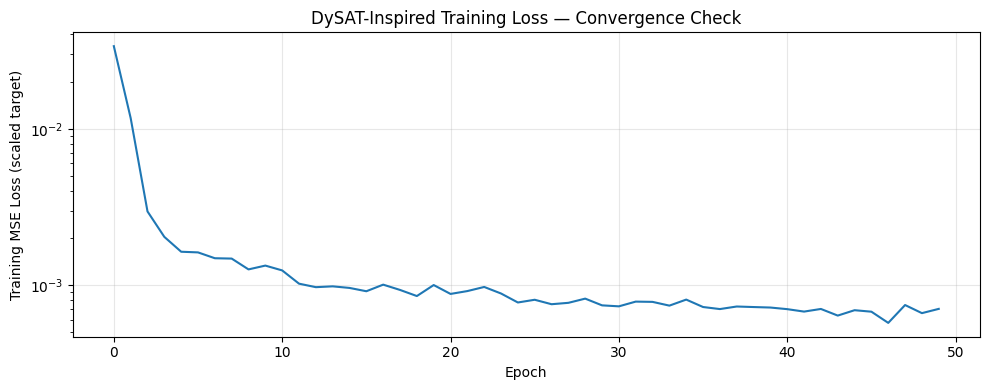


First 5 epochs avg loss: 0.010403
Last 5 epochs avg loss:  0.000673
Loss still decreasing in final 5 epochs: False


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss (scaled target)")
plt.title("DySAT-Inspired Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation on held-out (subsampled) test set

Compare this R² directly against the earlier failed run (R² = -0.016) and against GCN's benchmark (R² = 0.987) — that range tells you whether the fix worked, partially worked, or this architecture genuinely struggles with the task regardless of training budget.


In [11]:
dysat_model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test_sub), sub_batch_size):
        xb = X_test_sub[i:i+sub_batch_size].to(device)
        preds.append(dysat_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
dysat_pred_scaled = np.concatenate(preds).flatten()
dysat_pred = target_scaler_g.inverse_transform(dysat_pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_test_sub_true, dysat_pred)

print(f"DySAT-inspired ({N_EPOCHS} epochs, {SUBSAMPLE_SIZE}-row subsample) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print()
print("For reference:")
print(f"  Original run (3 epochs, 3000-row subsample):  RMSE=10.8501  MAE=7.5907  R2=-0.0161")
print(f"  GCN benchmark (best GNN, full test set):       RMSE=1.1938   MAE=0.6452  R2=0.9870")

DySAT-inspired (50 epochs, 6000-row subsample) — RMSE: 1.3140  MAE: 0.9593  R2: 0.9848

For reference:
  Original run (3 epochs, 3000-row subsample):  RMSE=10.8501  MAE=7.5907  R2=-0.0161
  GCN benchmark (best GNN, full test set):       RMSE=1.1938   MAE=0.6452  R2=0.9870


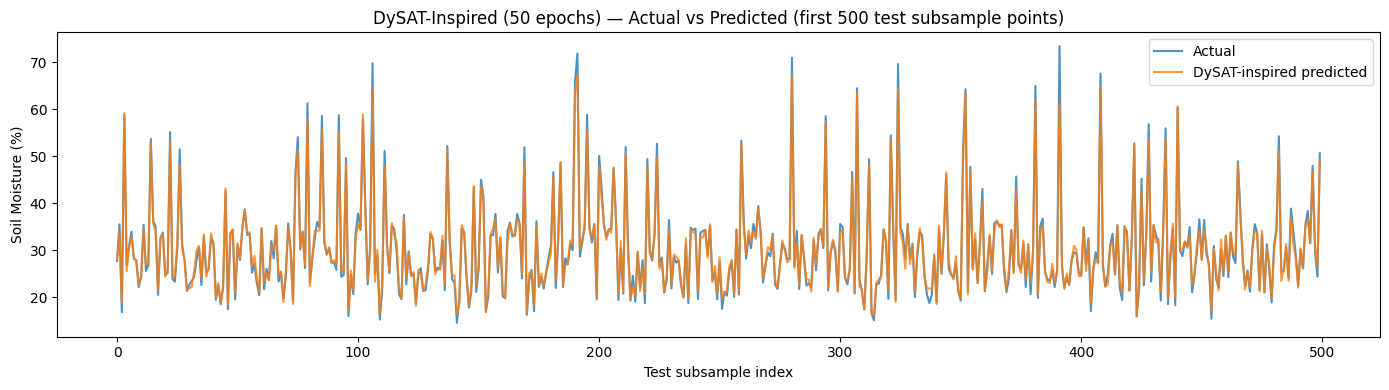

In [12]:
# Visual sanity check — predicted vs actual on the test subsample
plt.figure(figsize=(14, 4))
plt.plot(y_test_sub_true[:500], label="Actual", alpha=0.8)
plt.plot(dysat_pred[:500], label="DySAT-inspired predicted", alpha=0.8)
plt.title(f"DySAT-Inspired ({N_EPOCHS} epochs) — Actual vs Predicted (first 500 test subsample points)")
plt.xlabel("Test subsample index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

## If it still hasn't converged after this

A few next things to try, in order of how likely they are to matter:
1. **Increase `N_EPOCHS` further** (e.g. 50) — Transformer components often need more steps than convolutional GNN layers to settle, especially with limited data.
2. **Increase `SUBSAMPLE_SIZE`** (e.g. 10,000+) — the temporal self-attention has more parameters than GCN/GAT; more training examples may matter more here than for the simpler architectures.
3. **Try `num_layers=2`** in the `TransformerEncoder` — one layer of temporal attention may be too shallow to capture useful structure; be aware this roughly doubles per-sample compute cost.
4. **Try removing the GAT structural-attention step** (use GCN instead) — isolates whether the temporal-attention half or the structural-attention half is the harder component to train, consistent with what you already learned from GIN vs. GCN.

If none of these help, that's a legitimate, reportable finding: *"The DySAT-inspired model, even with stabilization and extended training, did not reliably converge on this small graph — consistent with the pattern seen across this project's more complex architectures (GAT, GIN, A3T-GCN), where added parameterization did not translate to better performance on a 6-node graph with limited structural complexity to exploit."* That ties directly into your GCN-vs-complexity narrative from the main notebook — a coherent thread across your whole Track B analysis, not a one-off failure.
